# Introduction to Apache Spark Resilient Distributed Datasets (RDD)

### Initialization ###
Starting Spark session:

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/09 08:30:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
spark

In [4]:
sc = spark.sparkContext

### Reading text files

Download a file locally (just for the demo, for larger files use HDFS or S3):

In [5]:
import urllib.request

In [6]:
urllib.request.urlretrieve("http://raw.githubusercontent.com/elastic/examples/master/Common%20Data%20Formats/apache_logs/apache_logs","apache_logs")

('apache_logs', <http.client.HTTPMessage at 0x108f6fa90>)

Create a first RDD

In [7]:
lines = sc.textFile("apache_logs")

Perform a *transformation*

In [8]:
lineLengths = lines.map(lambda s: len(s))

Perform an *action*

In [9]:
totalLength = lineLengths.reduce(lambda a, b: a + b)

Finally evaluate (laziness!)

In [10]:
totalLength

2360789

### Custom functions

In [11]:
def myFunc(s):
    words = s.split(" ")
    return len(words)

In [12]:
wordCounts = lines.map(myFunc)

In [13]:
wordCounts.max()

43

In [14]:
wordCounts.histogram([0,10,20,30,40,50])

([0, 10, 20, 30, 40, 50], [0, 4901, 4719, 378, 2])

In [15]:
wordCounts.count()

10000

### Map-Reduce pattern

Let's look closer at our log file format:

```
99.158.0.150 - - [18/May/2015:04:05:37 +0000] "GET /images/jordan-80.png HTTP/1.1" 200 6146 "http://www.semicomplete.com/articles/dynamic-dns-with-dhcp/" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Ubuntu Chromium/32.0.1700.102 Chrome/32.0.1700.102 Safari/537.36"
```

Count lines containing "Chrome":

In [16]:
chromeLines = lines.map(lambda s: (1 if "Chrome" in s else 0))

In [17]:
counts = chromeLines.reduce(lambda a, b: a + b)

In [18]:
counts

3172

### Key-Value Pairs

Count IP addresses

In [19]:
regex = '([(\d\.)]+)'

In [20]:
import re

In [21]:
ip = re.match(regex, '99.158.0.150 - - ').group(0)

In [22]:
print(ip)

99.158.0.150


In [23]:
ips = lines.map(lambda s: (re.match(regex, s).group(0) ,1))

In [24]:
ipCounts = ips.reduceByKey(lambda a, b: a + b)

Get results

In [25]:
ipCounts.collect()

[('83.149.9.216', 23),
 ('24.236.252.67', 1),
 ('93.114.45.13', 6),
 ('66.249.73.135', 482),
 ('50.16.19.13', 113),
 ('66.249.73.185', 56),
 ('50.150.204.184', 1),
 ('207.241.237.225', 13),
 ('200.49.190.101', 3),
 ('200.49.190.100', 1),
 ('67.214.178.190', 2),
 ('207.241.237.227', 17),
 ('207.241.237.228', 16),
 ('207.241.237.101', 17),
 ('209.85.238.199', 102),
 ('218.30.103.62', 16),
 ('74.125.40.20', 2),
 ('71.212.224.97', 5),
 ('108.174.55.234', 23),
 ('198.46.149.143', 82),
 ('50.180.79.170', 2),
 ('105.235.130.196', 6),
 ('54.255.13.204', 6),
 ('24.233.162.179', 1),
 ('220.181.108.153', 1),
 ('65.19.138.34', 3),
 ('97.116.185.190', 6),
 ('5.255.72.168', 2),
 ('71.207.12.53', 2),
 ('146.1.1.2', 15),
 ('178.255.215.83', 22),
 ('85.170.84.143', 5),
 ('100.43.83.137', 84),
 ('112.110.247.238', 1),
 ('94.228.34.233', 7),
 ('79.185.184.23', 6),
 ('207.241.237.102', 13),
 ('66.168.50.129', 1),
 ('82.247.137.135', 6),
 ('86.182.52.145', 6),
 ('180.76.5.27', 1),
 ('173.192.238.41', 3),
 

In [26]:
ipCounts.take(20)

[('83.149.9.216', 23),
 ('24.236.252.67', 1),
 ('93.114.45.13', 6),
 ('66.249.73.135', 482),
 ('50.16.19.13', 113),
 ('66.249.73.185', 56),
 ('50.150.204.184', 1),
 ('207.241.237.225', 13),
 ('200.49.190.101', 3),
 ('200.49.190.100', 1),
 ('67.214.178.190', 2),
 ('207.241.237.227', 17),
 ('207.241.237.228', 16),
 ('207.241.237.101', 17),
 ('209.85.238.199', 102),
 ('218.30.103.62', 16),
 ('74.125.40.20', 2),
 ('71.212.224.97', 5),
 ('108.174.55.234', 23),
 ('198.46.149.143', 82)]

Sort by values (ascending):

In [27]:
ipCounts.takeOrdered(10, lambda pair: pair[1])

[('24.236.252.67', 1),
 ('50.150.204.184', 1),
 ('200.49.190.100', 1),
 ('24.233.162.179', 1),
 ('220.181.108.153', 1),
 ('112.110.247.238', 1),
 ('66.168.50.129', 1),
 ('180.76.5.27', 1),
 ('93.164.60.142', 1),
 ('94.175.135.116', 1)]

Sort by values (descending):

In [34]:
topIPs = ipCounts.takeOrdered(10, lambda pair: -pair[1])
topIPs

[('46.105.14.53', 364),
 ('130.237.218.86', 357),
 ('75.97.9.59', 273),
 ('50.16.19.13', 113),
 ('209.85.238.199', 102),
 ('68.180.224.225', 99),
 ('100.43.83.137', 84),
 ('208.115.111.72', 83),
 ('198.46.149.143', 82),
 ('208.115.113.88', 74)]

25/10/09 10:22:43 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 907724 ms exceeds timeout 120000 ms
25/10/09 10:22:43 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/09 10:22:50 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:342)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

### Plotting

In [29]:
import pandas as pd

In [30]:
df = pd.DataFrame(topIPs, columns=['IP', 'Count'])
df

,IP,Count
0,66.249.73.135,482
1,46.105.14.53,364
2,130.237.218.86,357
3,75.97.9.59,273
4,50.16.19.13,113
5,209.85.238.199,102
6,68.180.224.225,99
7,100.43.83.137,84
8,208.115.111.72,83
9,198.46.149.143,82


In [32]:
import matplotlib.pyplot as plt

<Axes: ylabel='IP'>

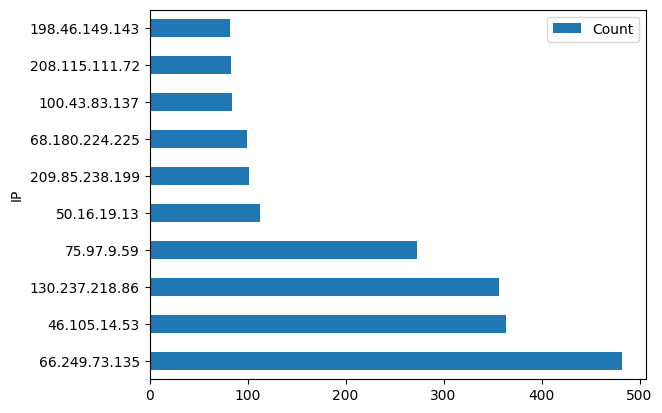

In [33]:
df.plot.barh(x = 'IP')

### Closures and accumulators

Local variables are not passed to closures or functions, they remain local!

In [32]:
counter = 0

# Wrong: Don't do this!!
def increment_counter(x):
    global counter
    counter += x

wordCounts.foreach(increment_counter)

print("Counter value: ", counter)

Counter value:  0


Use *accumulators* instead

In [33]:
accum = sc.accumulator(0)
accum

Accumulator<id=0, value=0>

In [34]:
# Correct way is to use accumulators
def increment_counter(x):
    accum.add(x)

wordCounts.foreach(increment_counter)

print("Counter value: ", accum)

Counter value:  197956
